# Swiggy Data Analysis

### Import Libraries

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
import plotly.express as px

### Import Data

In [72]:
df = pd.read_excel('swiggy_data.xlsx')
# df.head()

### Analyse Metadata

In [73]:
print("Number of Rows: ",df.shape[0])

Number of Rows:  197430


In [74]:
print("Number of Columns: ",df.shape[1])

Number of Columns:  10


### Data Type

In [75]:
df.dtypes

,0
State,object
City,object
Order Date,datetime64[ns]
Restaurant Name,object
Location,object
Category,object
Dish Name,object
Price (INR),float64
Rating,float64
Rating Count,int64


## KPIs

### Total Sales

In [76]:
total_sales = df["Price (INR)"].sum()
print("Total Sales (INR) : ",round(total_sales,2))

Total Sales (INR) :  53012505.77


### Average Rating

In [77]:
average_rating = df["Rating"].mean()
print("Average Rating : ",round(average_rating,2))

Average Rating :  4.34


### Average Order Value

In [78]:
average_OV = df["Price (INR)"].mean()
print("Average Order Value : ",round(average_OV,2))

Average Order Value :  268.51


### Rating Count

In [79]:
rating_count = df["Rating Count"].sum()
print("Total Rating Count : ",rating_count)

Total Rating Count :  5591574


### Total Food Orders

In [80]:
total_orders = df["Order Date"].count()
print("Total Orders : ",total_orders)

Total Orders :  197430


## Charts

### Monthly Sales Trend

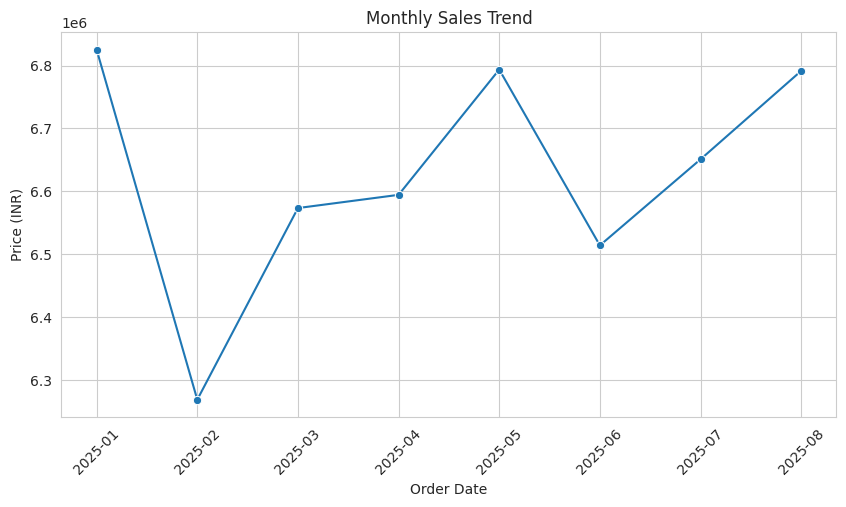

In [81]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

monthly_sales = (
    df.groupby(df["Order Date"].dt.to_period("M"))["Price (INR)"]
    .sum()
    .reset_index()
)

monthly_sales["Order Date"] = monthly_sales["Order Date"].astype(str)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_sales,
    x="Order Date",
    y="Price (INR)",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xticks(rotation=45)

plt.show()

### Daily Sales Trend

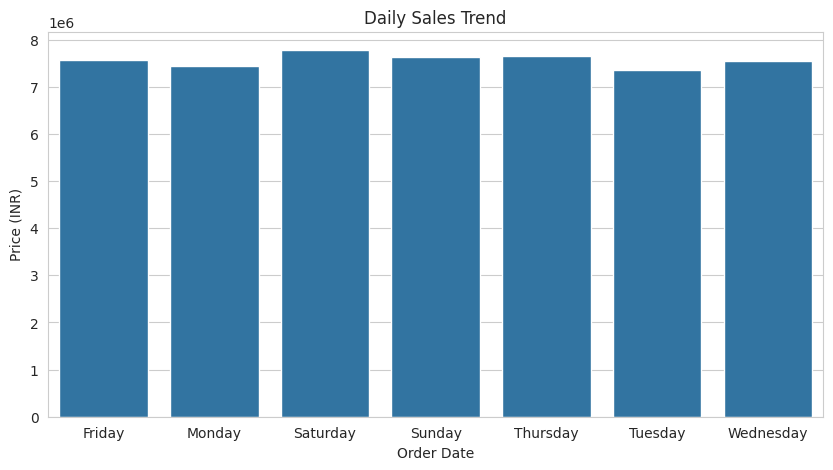

In [82]:
daily_sales = (
    df.groupby(df["Order Date"].dt.day_name())["Price (INR)"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=daily_sales,
    x="Order Date",
    y="Price (INR)"
)

plt.title("Daily Sales Trend")

plt.show()

### Total Sales by State

<Axes: title={'center': 'Sales by State'}, xlabel='State'>

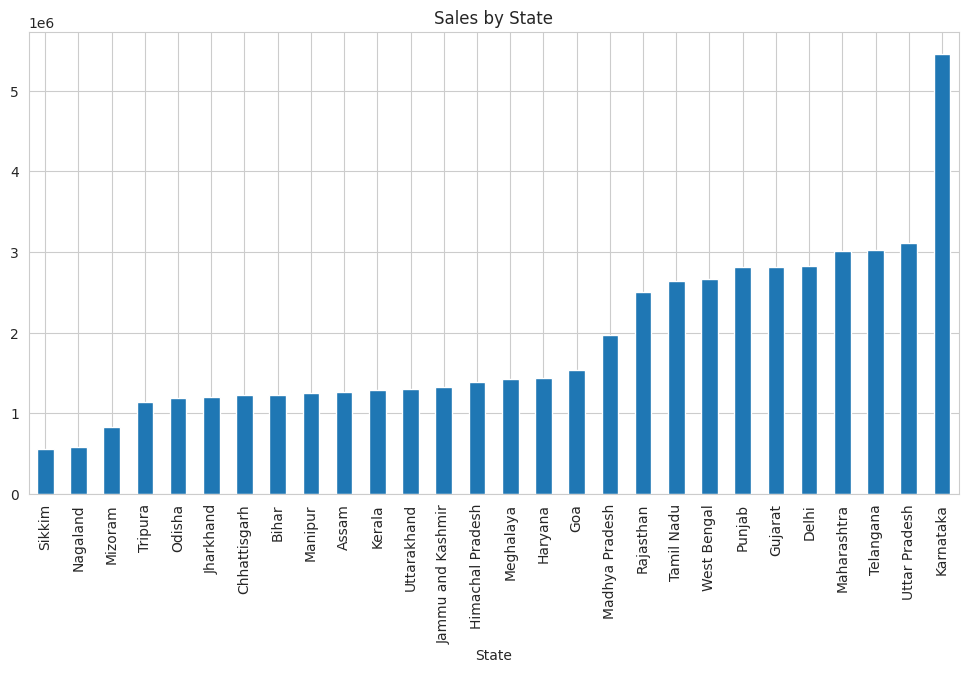

In [83]:
state_sales = (
    df.groupby("State")["Price (INR)"]
    .sum()
    .sort_values(ascending=True)
)

state_sales.plot(
    kind="bar",
    figsize=(12,6),
    title="Sales by State"
)

### Quarterly Performance Summary

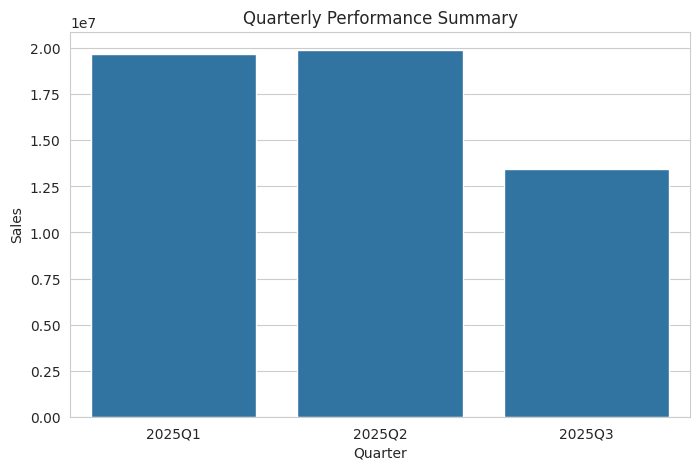

In [84]:
quarterly["Quarter"] = quarterly["Quarter"].astype(str)

plt.figure(figsize=(8,5))

sns.barplot(
    data=quarterly,
    x="Quarter",
    y="Price (INR)"
)

plt.title("Quarterly Performance Summary")
plt.xlabel("Quarter")
plt.ylabel("Sales")

plt.show()

### Top 5 Cities by Sales

<Axes: title={'center': 'Top 5 Cities by Sales'}, xlabel='City'>

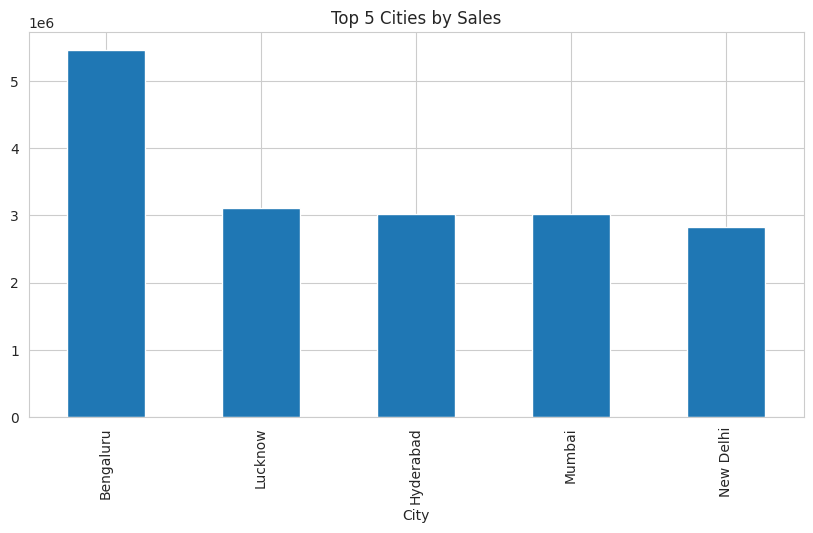

In [85]:
top_cities = (
    df.groupby("City")["Price (INR)"]
    .sum()
    .sort_values(ascending=False)
    .head(5)
)

top_cities.plot(
    kind="bar",
    figsize=(10,5),
    title="Top 5 Cities by Sales"
)

### Weekly Trend Analysis

<Axes: title={'center': 'Weekly Sales Trend'}, xlabel='week'>

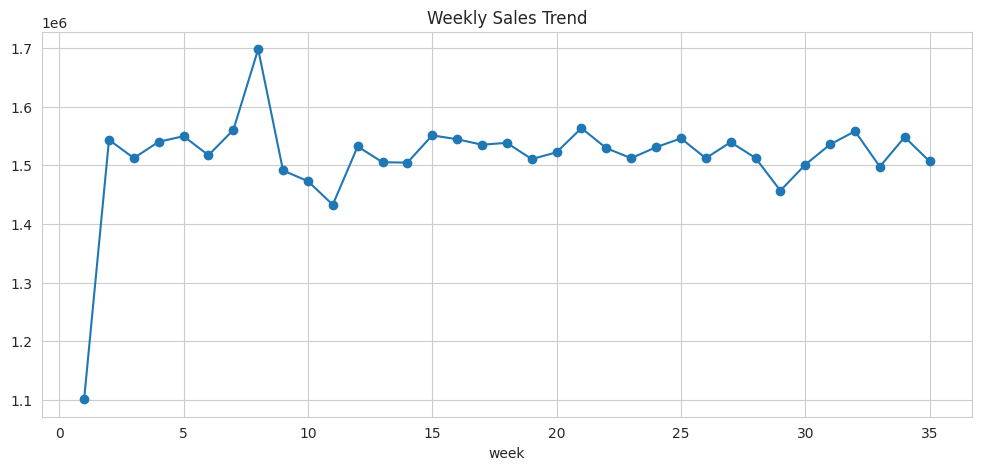

In [86]:
weekly_sales = (
    df.groupby(df["Order Date"].dt.isocalendar().week)["Price (INR)"]
    .sum()
)

weekly_sales.plot(
    kind="line",
    figsize=(12,5),
    marker="o",
    title="Weekly Sales Trend"
)